# Семинар: токенайзеры, размеры тензоров и attention

В этом ноутбуке три части:

1. **Токенайзеры**: сравниваем разные токенайзеры из `transformers` на английском, русском, китайском и коде.
2. **Перемножение тензоров**: учимся следить за размерами в линейных слоях и батчах.
3. **Attention**: смотрим параметры модели, предсказываем размеры тензоров и визуализируем attention.


## 0. Установка и импорты

In [1]:
# Если чего-то не хватает, раскомментируйте:
# !pip install -q transformers sentencepiece matplotlib torch

import math
import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from transformers import (
    AutoTokenizer,
    AutoConfig,
    AutoModel,
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
)

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)


ModuleNotFoundError: No module named 'torch'

# 1. Токенайзеры

Будем смотреть, как разные токенайзеры режут:
- английский,
- русский,
- китайский,
- код.

Важно: один и тот же текст может разбиваться очень по-разному. Это зависит от:
- алгоритма токенизации,
- словаря,
- языков, на которых обучали токенайзер,
- того, использует ли он byte-level BPE, SentencePiece и т.д.


In [ ]:
texts = {
    'english': 'The small dog sleeps on the carpet.',
    'russian': 'Маленькая собака спит на коврике.',
    'chinese': '小狗睡在地毯上。',
    'code': 'def attention(q, k, v):\n    return softmax(q @ k.T) @ v',
}

tokenizer_names = {
    'bert-base-uncased': 'BERT WordPiece',
    'gpt2': 'GPT-2 byte-level BPE',
    'google/mt5-small': 'mT5 SentencePiece',
    'xlm-roberta-base': 'XLM-R SentencePiece',
}

def inspect_tokenizer(tok_name, text):
    tok = AutoTokenizer.from_pretrained(tok_name)
    encoded = tok(text, return_tensors='pt')
    tokens = tok.convert_ids_to_tokens(encoded['input_ids'][0])
    print(f'=== {tok_name} ===')
    print('Text:   ', repr(text))
    print('Tokens: ', tokens)
    print('N toks: ', len(tokens))
    print("vocab_size:", tok.vocab_size)
    print("full_vocab_size:", len(tok.get_vocab()))
    print()

for tok_name in tokenizer_names:
    for lang, text in texts.items():
        inspect_tokenizer(tok_name, text)


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

=== bert-base-uncased ===
Text:    'The small dog sleeps on the carpet.'
Tokens:  ['[CLS]', 'the', 'small', 'dog', 'sleeps', 'on', 'the', 'carpet', '.', '[SEP]']
N toks:  10
vocab_size: 30522
full_vocab_size: 30522

=== bert-base-uncased ===
Text:    'Маленькая собака спит на коврике.'
Tokens:  ['[CLS]', 'м', '##а', '##л', '##е', '##н', '##ь', '##ка', '##я', 'с', '##о', '##б', '##а', '##ка', 'с', '##п', '##и', '##т', 'н', '##а', 'к', '##ов', '##р', '##и', '##к', '##е', '.', '[SEP]']
N toks:  28
vocab_size: 30522
full_vocab_size: 30522

=== bert-base-uncased ===
Text:    '小狗睡在地毯上。'
Tokens:  ['[CLS]', '小', '[UNK]', '[UNK]', '[UNK]', '地', '[UNK]', '上', '。', '[SEP]']
N toks:  10
vocab_size: 30522
full_vocab_size: 30522

=== bert-base-uncased ===
Text:    'def attention(q, k, v):\n    return softmax(q @ k.T) @ v'
Tokens:  ['[CLS]', 'def', 'attention', '(', 'q', ',', 'k', ',', 'v', ')', ':', 'return', 'soft', '##max', '(', 'q', '@', 'k', '.', 't', ')', '@', 'v', '[SEP]']
N toks:  24
vocab_si

...

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

=== xlm-roberta-base ===
Text:    'The small dog sleeps on the carpet.'
Tokens:  ['<s>', '▁The', '▁small', '▁dog', '▁sleep', 's', '▁on', '▁the', '▁carpet', '.', '</s>']
N toks:  11
vocab_size: 250002
full_vocab_size: 250002

=== xlm-roberta-base ===
Text:    'Маленькая собака спит на коврике.'
Tokens:  ['<s>', '▁', 'Маленьк', 'ая', '▁собак', 'а', '▁с', 'пит', '▁на', '▁ко', 'ври', 'ке', '.', '</s>']
N toks:  14
vocab_size: 250002
full_vocab_size: 250002

=== xlm-roberta-base ===
Text:    '小狗睡在地毯上。'
Tokens:  ['<s>', '▁小', '狗', '睡', '在地', '毯', '上', '。', '</s>']
N toks:  9
vocab_size: 250002
full_vocab_size: 250002

=== xlm-roberta-base ===
Text:    'def attention(q, k, v):\n    return softmax(q @ k.T) @ v'
Tokens:  ['<s>', '▁de', 'f', '▁attention', '(', 'q', ',', '▁k', ',', '▁v', '):', '▁return', '▁soft', 'max', '(', 'q', '▁@', '▁k', '.', 'T', ')', '▁@', '▁v', '</s>']
N toks:  24
vocab_size: 250002
full_vocab_size: 250002



## 1.1. Более аккуратное сравнение

Сделаем таблицу числа токенов для разных текстов и токенайзеров.

In [ ]:
rows = []
for tok_name, tok_descr in tokenizer_names.items():
    tok = AutoTokenizer.from_pretrained(tok_name)
    row = {'tokenizer': tok_descr}
    for lang, text in texts.items():
        n = len(tok(text)['input_ids'])
        row[lang] = n
    rows.append(row)

for row in rows:
    print(row)


{'tokenizer': 'BERT WordPiece', 'english': 10, 'russian': 28, 'chinese': 10, 'code': 24}
{'tokenizer': 'GPT-2 byte-level BPE', 'english': 8, 'russian': 35, 'chinese': 16, 'code': 25}
{'tokenizer': 'mT5 SentencePiece', 'english': 11, 'russian': 13, 'chinese': 10, 'code': 23}
{'tokenizer': 'XLM-R SentencePiece', 'english': 11, 'russian': 14, 'chinese': 9, 'code': 24}


## 1.2. Вопросы для обсуждения

1. Почему один и тот же русский текст у разных токенайзеров дает разное число токенов?
2. Почему код часто режется иначе, чем обычный текст?
3. Почему для multilingual-моделей токенизация русского обычно лучше, чем у чисто английских моделей?
4. Почему byte-level токенизаторы иногда выглядят странно на не-английских языках?


# 2. Перемножение тензоров и размеры

Главный навык: **всегда подписывать размеры**.

Полезное правило:
- если умножаем `A @ B`, то внутренняя размерность должна совпадать;
- если `A` имеет форму `(m, n)`, а `B` форму `(n, k)`, то результат имеет форму `(m, k)`.

Для нейросетей обычно встречаются такие случаи:
- матрица на вектор,
- матрица на матрицу,
- линейный слой,
- батч объектов,
- батч последовательностей.


## 2.1. Матрица на вектор

In [ ]:
W = torch.randn(3, 5)   # (out_dim, in_dim)
x = torch.randn(5)      # (in_dim,)

y = W @ x

print('W.shape =', W.shape)
print('x.shape =', x.shape)
print('y.shape =', y.shape)


W.shape = torch.Size([3, 5])
x.shape = torch.Size([5])
y.shape = torch.Size([3])


Здесь:
- `W \in R^{3 x 5}`
- `x \in R^{5}`
- значит `y \in R^{3}`


## 2.2. Linear layer

В `PyTorch` линейный слой хранит веса формы `(out_features, in_features)`.

То есть если `Linear(5, 3)`, то:
- вход имеет последнюю размерность 5,
- выход имеет последнюю размерность 3.


In [ ]:
lin = nn.Linear(5, 3)
x = torch.randn(5)
y = lin(x)

print('lin.weight.shape =', lin.weight.shape)
print('lin.bias.shape   =', lin.bias.shape)
print('x.shape          =', x.shape)
print('y.shape          =', y.shape)


lin.weight.shape = torch.Size([3, 5])
lin.bias.shape   = torch.Size([3])
x.shape          = torch.Size([5])
y.shape          = torch.Size([3])


## 2.3. Батч объектов

In [ ]:
lin = nn.Linear(5, 3)
x = torch.randn(4, 5)   # batch_size = 4, feature_dim = 5
y = lin(x)

print('x.shape =', x.shape)
print('y.shape =', y.shape)


x.shape = torch.Size([4, 5])
y.shape = torch.Size([4, 3])


Правило: `Linear` действует по **последней размерности**, а все предыдущие размерности считаются батчевыми.

## 2.4. Батч последовательностей

Частый случай в NLP:
- `batch_size = B`
- `seq_len = T`
- `hidden_dim = d`

Тогда тензор скрытых состояний имеет форму:

\[
(B, T, d)
\]


In [ ]:
B, T, d_in, d_out = 2, 4, 5, 3
x = torch.randn(B, T, d_in)
lin = nn.Linear(d_in, d_out)
y = lin(x)

print('x.shape =', x.shape)
print('y.shape =', y.shape)


x.shape = torch.Size([2, 4, 5])
y.shape = torch.Size([2, 4, 3])


## 2.5. Упражнения на размеры

Попробуйте сначала **предсказать размер**, а потом выполнить код.

In [ ]:
# Упражнение 1
A = torch.randn(7, 11)
x = torch.randn(11)
y = A @ x
print('Exercise 1:', y.shape)

# Упражнение 2
A = torch.randn(8, 6)
B = torch.randn(6, 10)
C = A @ B
print('Exercise 2:', C.shape)

# Упражнение 3
x = torch.randn(3, 12, 64)
lin = nn.Linear(64, 128)
y = lin(x)
print('Exercise 3:', y.shape)

# Упражнение 4
x = torch.randn(2, 5, 4)
W = torch.randn(4, 7)
y = x @ W
print('Exercise 4:', y.shape)


Exercise 1: torch.Size([7])
Exercise 2: torch.Size([8, 10])
Exercise 3: torch.Size([3, 12, 128])
Exercise 4: torch.Size([2, 5, 7])


## 2.6. Как следить за размерами

Хорошая стратегия:

1. **Подписать смысл каждой оси**.
   Например: `(batch, seq, hidden)`.

2. **Подписать размеры до операции**.
   Например: `Q: (B, T, d_k)`, `K: (B, T, d_k)`.

3. **Понять, какие оси участвуют в умножении**.

4. **После операции снова подписать смысл осей**.

В attention это особенно важно, потому что там много размеров:
- batch,
- длина последовательности,
- число голов,
- размерность головы.


# 3. Attention и архитектура моделей

В этой части:
- загрузим несколько небольших моделей,
- посмотрим конфиг,
- выясним токенайзер,
- узнаем число слоев, голов и размерность,
- предскажем размеры attention-тензоров,
- найдем матрицы проекций,
- визуализируем attention.


## 3.1. Смотрим конфиги моделей

In [ ]:
model_names = [
    'distilbert-base-uncased',
    'gpt2',
    'google/mt5-small',
]

for name in model_names:
    cfg = AutoConfig.from_pretrained(name)
    print('=' * 80)
    print(name)
    print(cfg)
    print()


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

distilbert-base-uncased
DistilBertConfig {
  "activation": "gelu",
  "architectures": [
    "DistilBertForMaskedLM"
  ],
  "attention_dropout": 0.1,
  "bos_token_id": null,
  "dim": 768,
  "dropout": 0.1,
  "eos_token_id": null,
  "hidden_dim": 3072,
  "initializer_range": 0.02,
  "max_position_embeddings": 512,
  "model_type": "distilbert",
  "n_heads": 12,
  "n_layers": 6,
  "pad_token_id": 0,
  "qa_dropout": 0.1,
  "seq_classif_dropout": 0.2,
  "sinusoidal_pos_embds": false,
  "tie_weights_": true,
  "tie_word_embeddings": true,
  "transformers_version": "5.0.0",
  "vocab_size": 30522
}




config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

gpt2
GPT2Config {
  "activation_function": "gelu_new",
  "add_cross_attention": false,
  "architectures": [
    "GPT2LMHeadModel"
  ],
  "attn_pdrop": 0.1,
  "bos_token_id": 50256,
  "embd_pdrop": 0.1,
  "eos_token_id": 50256,
  "initializer_range": 0.02,
  "layer_norm_epsilon": 1e-05,
  "model_type": "gpt2",
  "n_ctx": 1024,
  "n_embd": 768,
  "n_head": 12,
  "n_inner": null,
  "n_layer": 12,
  "n_positions": 1024,
  "pad_token_id": null,
  "reorder_and_upcast_attn": false,
  "resid_pdrop": 0.1,
  "scale_attn_by_inverse_layer_idx": false,
  "scale_attn_weights": true,
  "summary_activation": null,
  "summary_first_dropout": 0.1,
  "summary_proj_to_labels": true,
  "summary_type": "cls_index",
  "summary_use_proj": true,
  "task_specific_params": {
    "text-generation": {
      "do_sample": true,
      "max_length": 50
    }
  },
  "tie_word_embeddings": true,
  "transformers_version": "5.0.0",
  "use_cache": true,
  "vocab_size": 50257
}




config.json:   0%|          | 0.00/553 [00:00<?, ?B/s]

google/mt5-small
MT5Config {
  "architectures": [
    "MT5ForConditionalGeneration"
  ],
  "bos_token_id": null,
  "classifier_dropout": 0.0,
  "d_ff": 1024,
  "d_kv": 64,
  "d_model": 512,
  "decoder_start_token_id": 0,
  "dense_act_fn": "gelu_new",
  "dropout_rate": 0.1,
  "eos_token_id": 1,
  "feed_forward_proj": "gated-gelu",
  "initializer_factor": 1.0,
  "is_decoder": false,
  "is_encoder_decoder": true,
  "is_gated_act": true,
  "layer_norm_epsilon": 1e-06,
  "model_type": "mt5",
  "num_decoder_layers": 8,
  "num_heads": 6,
  "num_layers": 8,
  "pad_token_id": 0,
  "relative_attention_max_distance": 128,
  "relative_attention_num_buckets": 32,
  "tie_word_embeddings": true,
  "tokenizer_class": "T5Tokenizer",
  "transformers_version": "5.0.0",
  "use_cache": true,
  "vocab_size": 250112
}




In [ ]:
from transformers import AutoModel, AutoModelForCausalLM, AutoModelForSeq2SeqLM

models_to_print = [
    ("distilbert-base-uncased", "encoder"),
    ("gpt2", "causal_lm"),
    ("google/mt5-small", "seq2seq"),
]

for name, kind in models_to_print:
    print("=" * 100)
    print(name)

    if kind == "encoder":
        model = AutoModel.from_pretrained(name)
    elif kind == "causal_lm":
        model = AutoModelForCausalLM.from_pretrained(name)
    elif kind == "seq2seq":
        model = AutoModelForSeq2SeqLM.from_pretrained(name)
    else:
        raise ValueError(f"Unknown kind: {kind}")

    print(model)
    print()

distilbert-base-uncased


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSelfAttention(
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): L

...

model.safetensors:   0%|          | 0.00/1.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

MT5ForConditionalGeneration(
  (shared): Embedding(250112, 512)
  (encoder): MT5Stack(
    (embed_tokens): Embedding(250112, 512)
    (block): ModuleList(
      (0): MT5Block(
        (layer): ModuleList(
          (0): MT5LayerSelfAttention(
            (SelfAttention): MT5Attention(
              (q): Linear(in_features=512, out_features=384, bias=False)
              (k): Linear(in_features=512, out_features=384, bias=False)
              (v): Linear(in_features=512, out_features=384, bias=False)
              (o): Linear(in_features=384, out_features=512, bias=False)
              (relative_attention_bias): Embedding(32, 6)
            )
            (layer_norm): MT5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): MT5LayerFF(
            (DenseReluDense): MT5DenseGatedActDense(
              (wi_0): Linear(in_features=512, out_features=1024, bias=False)
              (wi_1): Linear(in_features=512, out_features=1024, bias=False)
          

Вот базовая имплементация scaled_dot_product_attention https://docs.pytorch.org/docs/stable/generated/torch.nn.functional.scaled_dot_product_attention.html:


def scaled_dot_product_attention(query, key, value, attn_mask=None,   dropout_p=0.0, is_causal=False, scale=None, enable_gqa=False) -> torch.Tensor:

      L, S = query.size(-2), key.size(-2)
      scale_factor = 1 / math.sqrt(query.size(-1)) if scale is None else scale
      attn_bias = torch.zeros(L, S, dtype=query.dtype, device=query.device)
      if is_causal:
          assert attn_mask is None
          temp_mask = torch.ones(L, S, dtype=torch.bool).tril(diagonal=0)
          attn_bias.masked_fill_(temp_mask.logical_not(), float("-inf"))

      if attn_mask is not None:
          if attn_mask.dtype == torch.bool:
              attn_bias.masked_fill_(attn_mask.logical_not(), float("-inf"))
          else:
              attn_bias = attn_mask + attn_bias

      if enable_gqa:
          key = key.repeat_interleave(query.size(-3)//key.size(-3), -3)
          value = value.repeat_interleave(query.size(-3)//value.size(-3), -3)

      attn_weight = query @ key.transpose(-2, -1) * scale_factor
      attn_weight += attn_bias
      attn_weight = torch.softmax(attn_weight, dim=-1)
      attn_weight = torch.dropout(attn_weight, dropout_p, train=True)
      return attn_weight @ value

### К сведению: вот так выглядит слой MT5DenseGatedActDense https://github.com/huggingface/transformers/blob/main/src/transformers/models/mt5/modeling_mt5.py

class MT5DenseGatedActDense(nn.Module):

    def __init__(self, config: MT5Config):
        super().__init__()
        self.wi_0 = nn.Linear(config.d_model, config.d_ff, bias=False)
        self.wi_1 = nn.Linear(config.d_model, config.d_ff, bias=False)
        self.wo = nn.Linear(config.d_ff, config.d_model, bias=False)
        self.dropout = nn.Dropout(config.dropout_rate)
        self.act = ACT2FN[config.dense_act_fn]

    def forward(self, hidden_states):
        hidden_gelu = self.act(self.wi_0(hidden_states))
        hidden_linear = self.wi_1(hidden_states)
        hidden_states = hidden_gelu * hidden_linear
        hidden_states = self.dropout(hidden_states)

        # To make 8bit quantization work for google/flan-t5-xxl, self.wo is kept in float32.
        # See https://github.com/huggingface/transformers/issues/20287
        # we also make sure the weights are not in `int8` in case users will force `_keep_in_fp32_modules` to be `None``
        if (
            isinstance(self.wo.weight, torch.Tensor)
            and hidden_states.dtype != self.wo.weight.dtype
            and self.wo.weight.dtype != torch.int8
        ):
            hidden_states = hidden_states.to(self.wo.weight.dtype)

        hidden_states = self.wo(hidden_states)
        return hidden_states

## 3.2. Вытаскиваем ключевые параметры

In [ ]:
def extract_basic_params(cfg):
    hidden = getattr(cfg, 'hidden_size', None)
    if hidden is None:
        hidden = getattr(cfg, 'd_model', None)

    heads = getattr(cfg, 'num_attention_heads', None)
    if heads is None:
        heads = getattr(cfg, 'num_heads', None)

    layers = getattr(cfg, 'num_hidden_layers', None)
    if layers is None:
        layers = getattr(cfg, 'num_layers', None)
    if layers is None:
        layers = getattr(cfg, 'encoder_layers', None)

    return hidden, heads, layers

for name in model_names:
    cfg = AutoConfig.from_pretrained(name)
    hidden, heads, layers = extract_basic_params(cfg)
    print(f'{name:30s} hidden={hidden}, heads={heads}, layers={layers}')


distilbert-base-uncased        hidden=768, heads=12, layers=6
gpt2                           hidden=768, heads=12, layers=12
google/mt5-small               hidden=512, heads=6, layers=8


## 3.3. Предсказание размеров

Пусть:
- batch size = `B`
- seq len = `T`
- hidden size = `d_model`
- num heads = `h`
- head dim = `d_k = d_model / h`

Тогда обычно:

\[
X \in \mathbb{R}^{B \times T \times d_{model}}
\]

\[
Q, K, V \in \mathbb{R}^{B \times h \times T \times d_k}
\]

\[
QK^\top \in \mathbb{R}^{B \times h \times T \times T}
\]

То есть attention matrix для каждой головы имеет размер `T x T`.


In [ ]:
B = 2
T = 7
d_model = 768
h = 12
d_k = d_model // h

print('X      :', (B, T, d_model))
print('Q, K, V:', (B, h, T, d_k))
print('Scores :', (B, h, T, T))


X      : (2, 7, 768)
Q, K, V: (2, 12, 7, 64)
Scores : (2, 12, 7, 7)


## 3.4. Распечатываем модель и ищем attention-блоки

In [ ]:
model_name = 'distilbert-base-uncased'
tok = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

print(model)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSelfAttention(
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): L

## 3.5. Где искать `W_K`?

В разных моделях названия разные.

Например:
- у BERT-подобных моделей часто есть что-то вроде `attention.self.key`
- у GPT-подобных — объединенные проекции или отдельные `q_proj`, `k_proj`, `v_proj`
- у T5/mT5 — свои имена слоев.

Ниже посмотрим все параметры, в названии которых встречается `key`, `k_proj` или `c_attn`.


In [ ]:
for name, param in model.named_parameters():
    lname = name.lower()
    if ('key' in lname) or ('k_proj' in lname) or ('c_attn' in lname):
        print(name, tuple(param.shape))


Если хочется найти конкретный слой, можно смотреть, например, первый attention-блок и его веса.

In [ ]:
# Пример для DistilBERT: смотрим первый attention-модуль
first_block = model.transformer.layer[0].attention
print(first_block)

for name, param in first_block.named_parameters():
    print(name, tuple(param.shape))


DistilBertSelfAttention(
  (q_lin): Linear(in_features=768, out_features=768, bias=True)
  (k_lin): Linear(in_features=768, out_features=768, bias=True)
  (v_lin): Linear(in_features=768, out_features=768, bias=True)
  (out_lin): Linear(in_features=768, out_features=768, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
)
q_lin.weight (768, 768)
q_lin.bias (768,)
k_lin.weight (768, 768)
k_lin.bias (768,)
v_lin.weight (768, 768)
v_lin.bias (768,)
out_lin.weight (768, 768)
out_lin.bias (768,)


## 3.6. Визуализация attention

Возьмем маленькую модель и короткую фразу. Для encoder-only моделей удобно смотреть self-attention.


In [ ]:
model_name = 'distilbert-base-uncased'
tok = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name, attn_implementation='eager')
model.eval()

text = 'The small dog sleeps on the carpet, and dreams about electric sheep.'
batch = tok(text, return_tensors='pt')

with torch.no_grad():
    out = model(**batch, output_attentions=True, return_dict=True)

print(type(out.attentions), len(out.attentions))
print(out.attentions[0].shape)  # (batch, heads, seq, seq)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


<class 'tuple'> 6
torch.Size([1, 12, 16, 16])


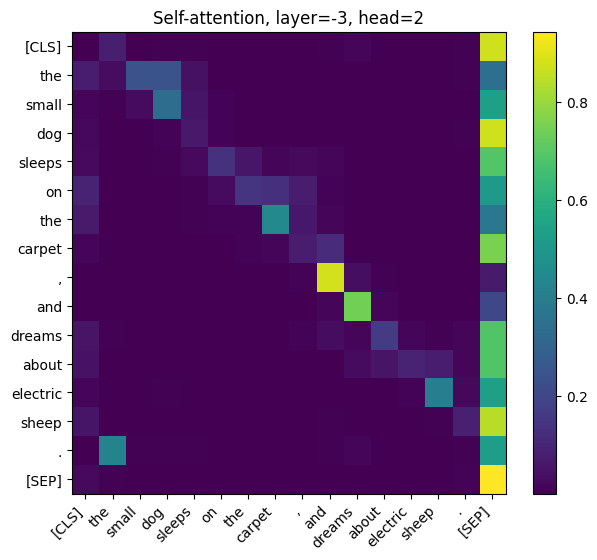

In [ ]:
layer = -3
head = 2

attn = out.attentions[layer][0, head].cpu().numpy()
tokens = tok.convert_ids_to_tokens(batch['input_ids'][0])

plt.figure(figsize=(7, 6))
plt.imshow(attn, aspect='auto')
plt.xticks(range(len(tokens)), tokens, rotation=45, ha='right')
plt.yticks(range(len(tokens)), tokens)
plt.title(f'Self-attention, layer={layer}, head={head}')
plt.colorbar()
plt.show()


## 3.7. Поиск интересных паттернов

Попробуйте:

1. Перебрать разные головы.
2. Перебрать разные слои.
3. Сравнить короткое и длинное предложение.
4. Посмотреть, есть ли головы, которые:
   - сильно смотрят на `[CLS]` или `[SEP]`,
   - имеют почти диагональный паттерн,
   - имеют вертикальные полосы,
   - выделяют пунктуацию.


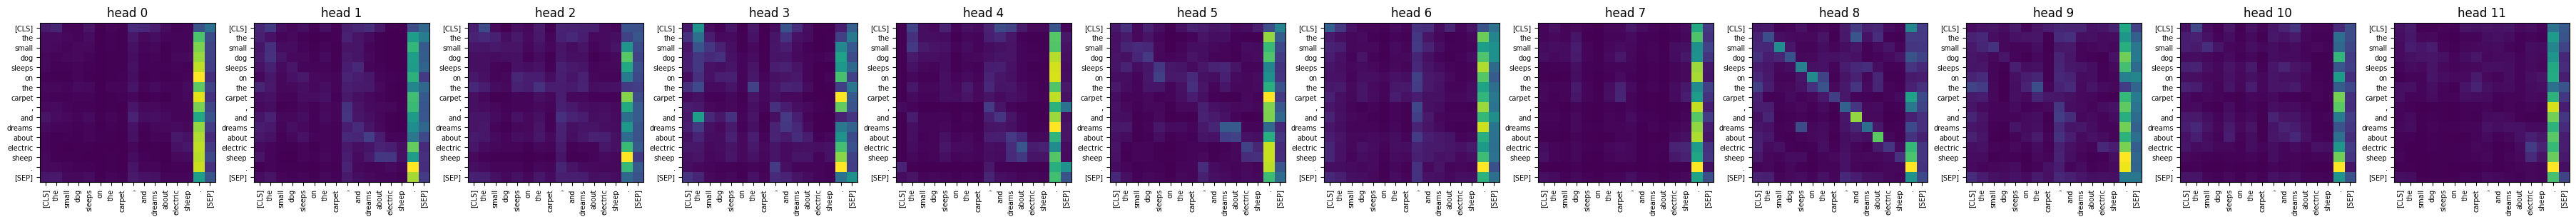

In [ ]:
# Перебор нескольких голов последнего слоя
layer = -1
num_heads = out.attentions[layer].shape[1]

fig, axes = plt.subplots(1, num_heads, figsize=(3 * num_heads, 3), constrained_layout=True)

for h in range(num_heads):
    ax = axes[h]
    mat = out.attentions[layer][0, h].cpu().numpy()
    ax.imshow(mat, aspect='auto')
    ax.set_title(f'head {h}')
    ax.set_xticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=90, fontsize=7)
    ax.set_yticks(range(len(tokens)))
    ax.set_yticklabels(tokens, fontsize=7)

plt.show()


# Домашние мини-упражнения

1. Взять еще один токенайзер и сравнить его на русском и на коде.
2. Для заданных `B, T, d_model, h` вручную выписать размеры `Q, K, V` и `QK^T`.
3. Для еще одной модели из `transformers` найти число слоев, голов и размерность. Есть ли в ее механизме внимания интересные особенности?
4. Найти конкретный параметр, который соответствует `W_K`.
5. Подобрать голову attention с наиболее интересным паттерном и описать его словами.
